In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/players_clean.csv')
print(f"Dataset: {df.shape[0]} players, {df.shape[1]} columns")
df.head()

Dataset: 25088 players, 17 columns


,player_id,name,position,sub_position,foot,height_in_cm,country_of_citizenship,current_club_name,current_club_domestic_competition_id,market_value_in_eur,highest_market_value_in_eur,games_played,total_goals,total_assists,total_minutes,total_yellow_cards,total_red_cards
0,10,Miroslav Klose,Attack,Centre-Forward,right,184.0,Germany,Società Sportiva Lazio S.p.A.,IT1,1000000.0,30000000.0,136.0,48.0,25.0,8808.0,19.0,0.0
1,26,Roman Weidenfeller,Goalkeeper,Goalkeeper,left,190.0,Germany,Borussia Dortmund,L1,750000.0,8000000.0,152.0,0.0,0.0,13508.0,4.0,2.0
2,65,Dimitar Berbatov,Attack,Centre-Forward,NaN,NaN,Bulgaria,Panthessalonikios Athlitikos Omilos Konstantin...,GR1,1000000.0,34500000.0,122.0,38.0,13.0,8788.0,11.0,1.0
3,77,Lúcio,Defender,Centre-Back,NaN,NaN,Brazil,Juventus Football Club,IT1,200000.0,24500000.0,4.0,0.0,0.0,307.0,0.0,0.0
4,80,Tom Starke,Goalkeeper,Goalkeeper,right,194.0,Germany,FC Bayern München,L1,100000.0,3000000.0,12.0,0.0,0.0,1080.0,0.0,0.0


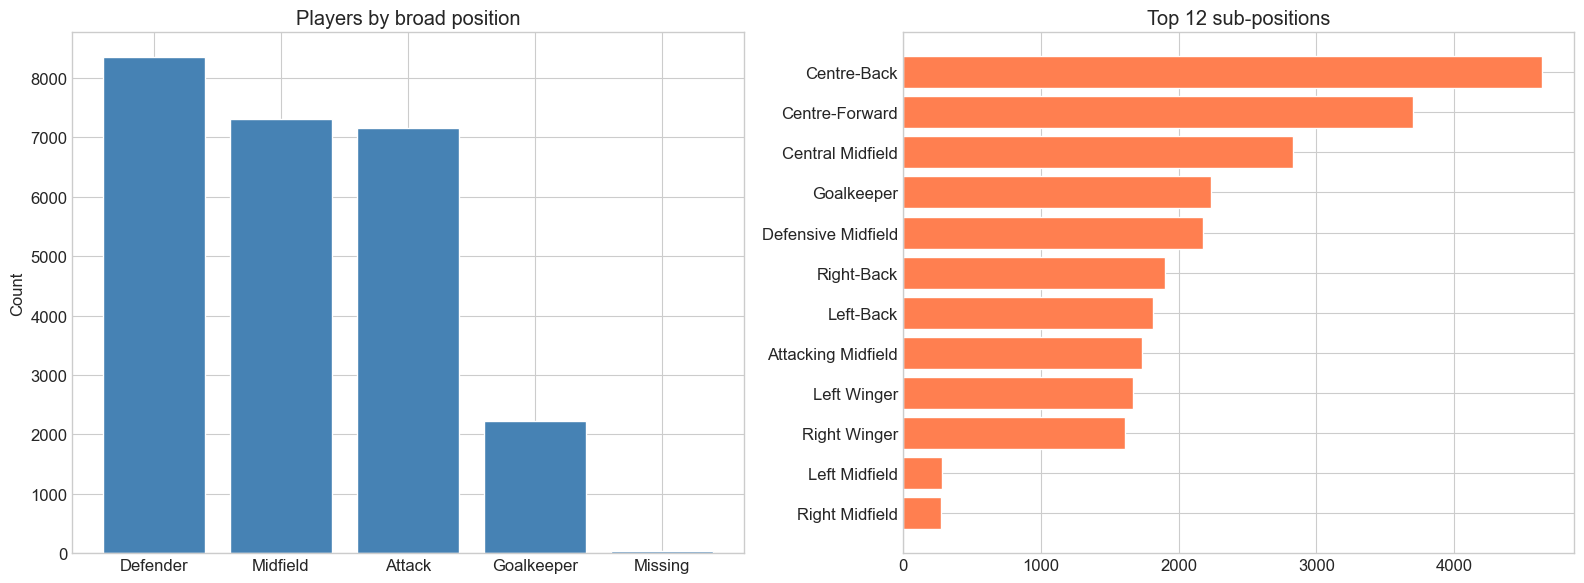

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

pos_counts = df['position'].value_counts()
ax1.bar(pos_counts.index, pos_counts.values, color='steelblue', edgecolor='white')
ax1.set_title('Players by broad position')
ax1.set_ylabel('Count')

sub_counts = df['sub_position'].value_counts().head(12)
ax2.barh(sub_counts.index, sub_counts.values, color='coral', edgecolor='white')
ax2.set_title('Top 12 sub-positions')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/positions.png', dpi=150, bbox_inches='tight')
plt.show()

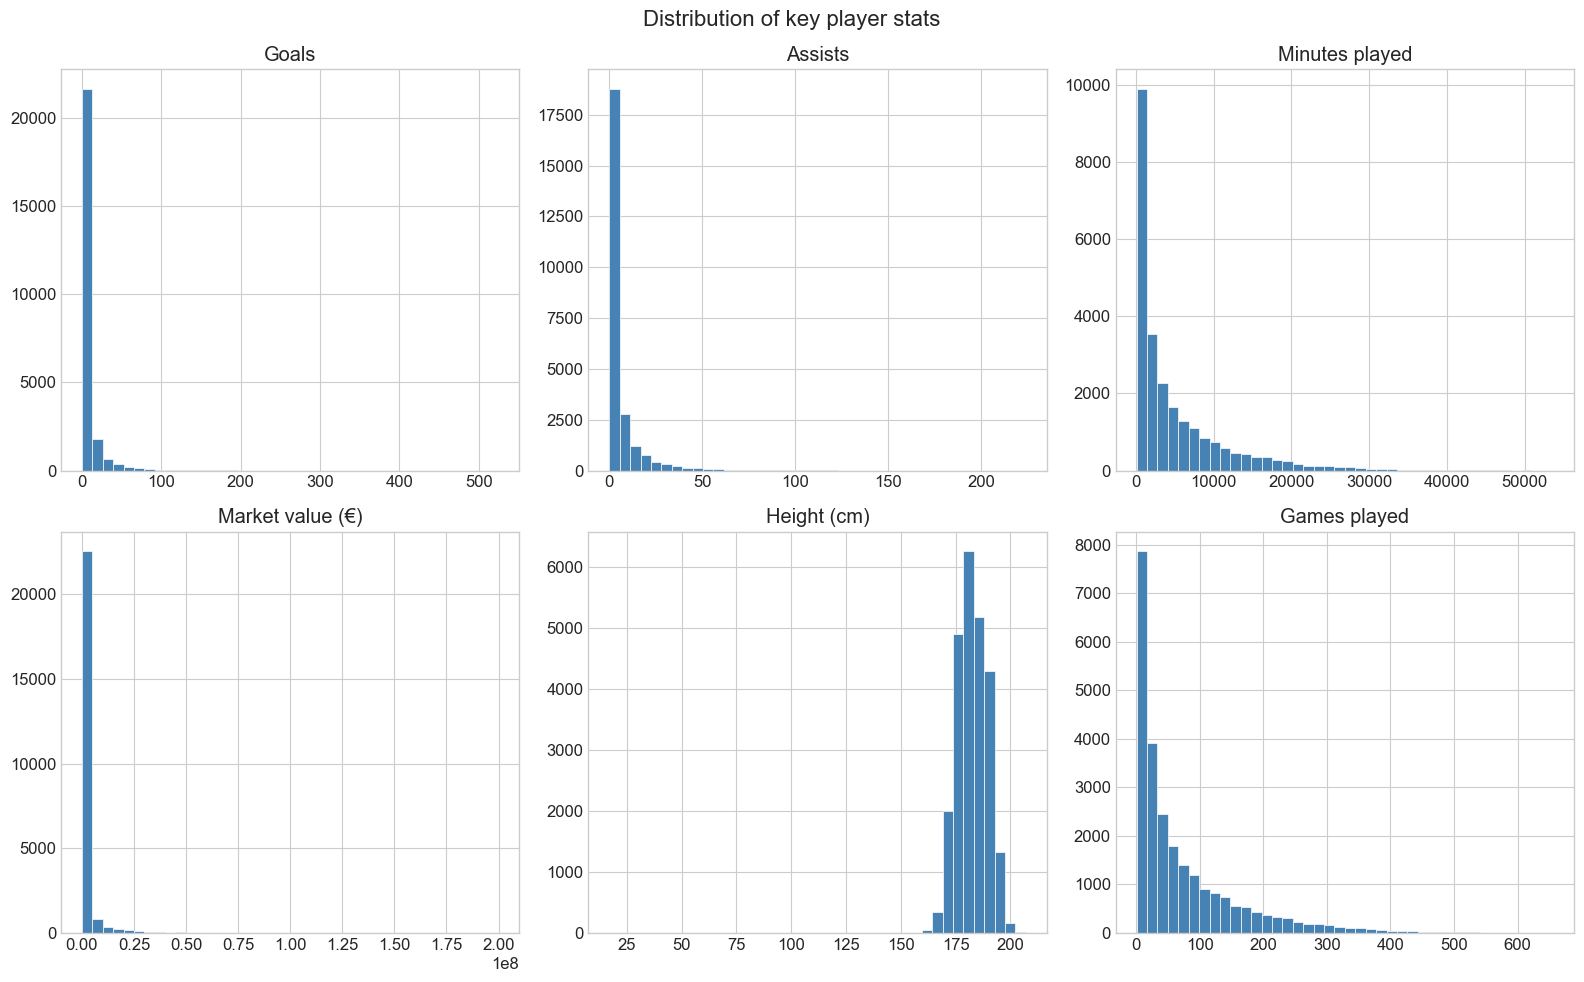

In [3]:
import os

# Create the outputs folder if it doesn't exist
if not os.path.exists('../outputs'):
    os.makedirs('../outputs')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of key player stats', fontsize=16)

cols = ['total_goals','total_assists','total_minutes',
        'market_value_in_eur','height_in_cm','games_played']
titles = ['Goals','Assists','Minutes played',
          'Market value (€)','Height (cm)','Games played']

for ax, col, title in zip(axes.flatten(), cols, titles):
    df[col].dropna().hist(ax=ax, bins=40, color='steelblue',
                          edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
df['goals_per90']         = (df['total_goals']        / df['total_minutes']) * 90
df['assists_per90']       = (df['total_assists']      / df['total_minutes']) * 90
df['goal_contributions']  = df['total_goals'] + df['total_assists']
df['gc_per90']            = (df['goal_contributions'] / df['total_minutes']) * 90
df['yellow_cards_per90']  = (df['total_yellow_cards'] / df['total_minutes']) * 90
df['minutes_ratio']       = df['total_minutes'] / df['total_minutes'].max()

df[['name','position','goals_per90','assists_per90','gc_per90']].sort_values(
    'gc_per90', ascending=False
).head(10)

,name,position,goals_per90,assists_per90,gc_per90
2421,Dusan Predrag Djuric,Midfield,0.937500,1.875000,2.812500
23086,Osman Addo,Attack,2.195122,0.439024,2.634146
13073,Carlo de Reuver,Attack,2.195122,0.000000,2.195122
22992,Hilmir Rafn Mikaelsson,Attack,2.000000,0.000000,2.000000
25086,Bachir Gueye,Attack,2.000000,0.000000,2.000000
20674,Arman Taranis,Attack,0.957447,0.957447,1.914894
21704,Özgür Sert,Midfield,0.957447,0.957447,1.914894
15939,Ferdinando Del Sole,Attack,1.862069,0.000000,1.862069
23202,Steven Nsimba,Attack,1.836735,0.000000,1.836735
14691,Issa Baradji,Attack,1.800000,0.000000,1.800000


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20352\316238788.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='position', y='goals_per90',
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20352\316238788.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='position', y='assists_per90',
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20352\316238788.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='position', y='market_value_in_eur',


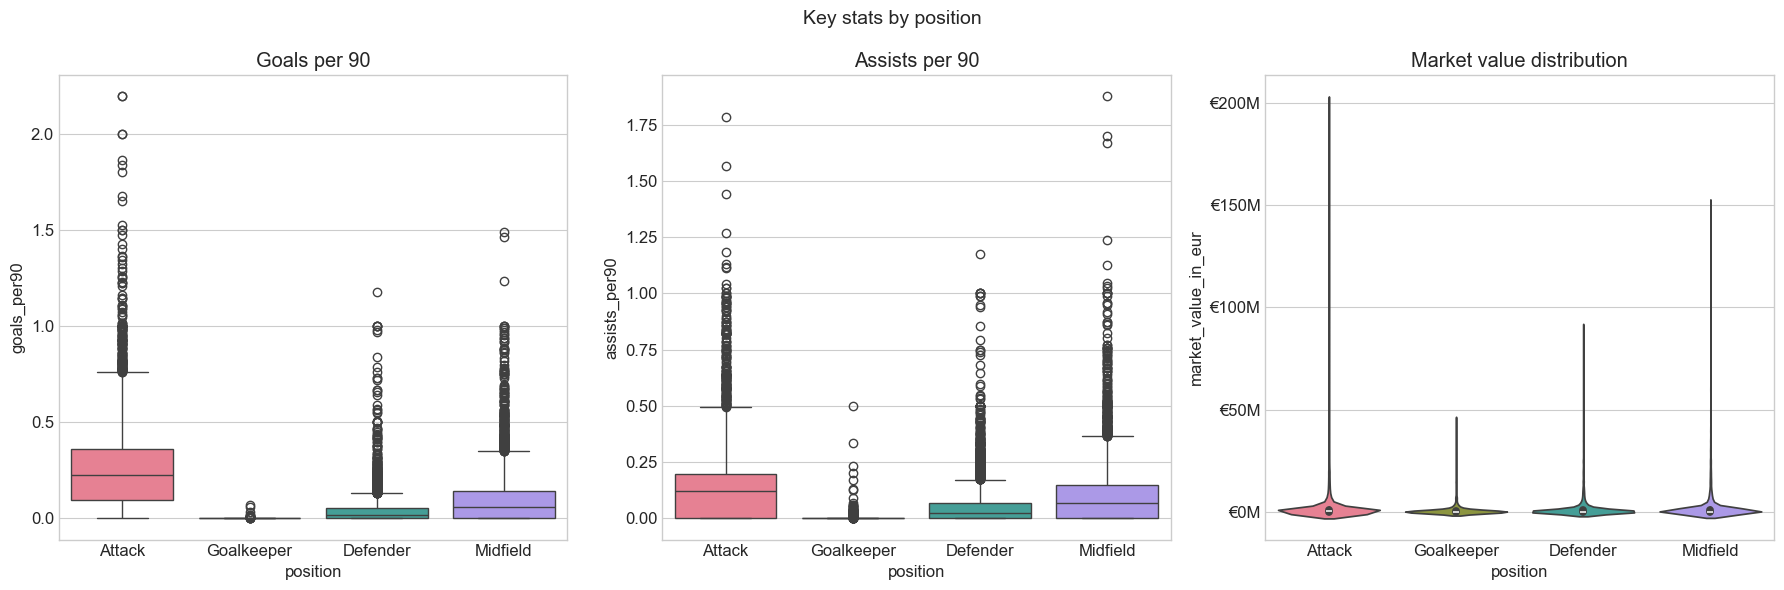

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Key stats by position', fontsize=14)

plot_data = df[df['position'].isin(['Attack','Midfield','Defender','Goalkeeper'])]

sns.boxplot(data=plot_data, x='position', y='goals_per90',
            ax=axes[0], palette='husl')
axes[0].set_title('Goals per 90')

sns.boxplot(data=plot_data, x='position', y='assists_per90',
            ax=axes[1], palette='husl')
axes[1].set_title('Assists per 90')

sns.violinplot(data=plot_data, x='position', y='market_value_in_eur',
               ax=axes[2], palette='husl')
axes[2].set_title('Market value distribution')
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('../outputs/position_comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

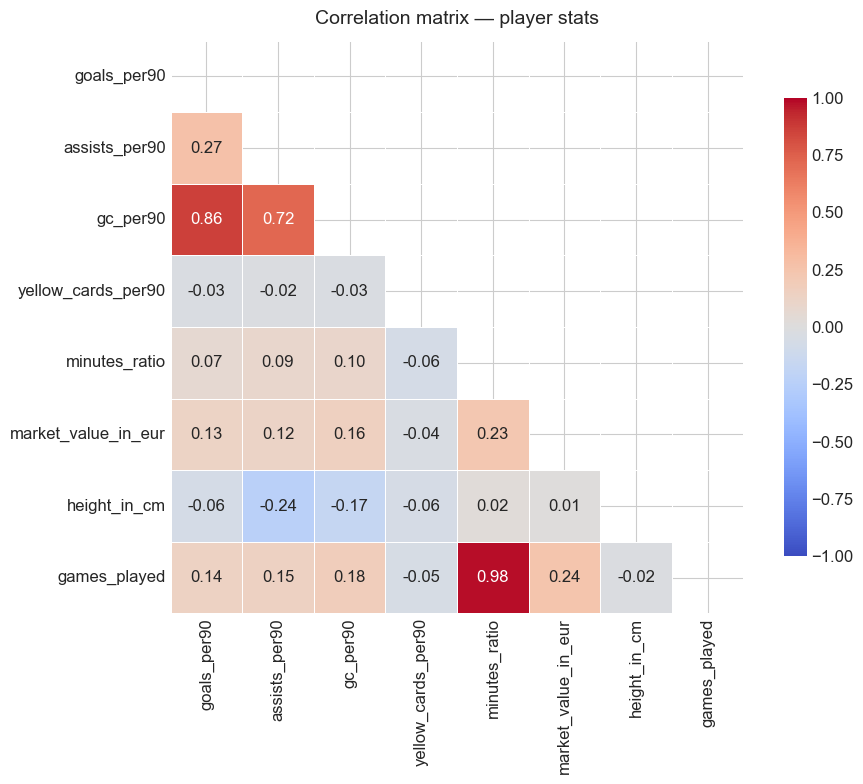

In [6]:
numeric_cols = ['goals_per90','assists_per90','gc_per90',
                'yellow_cards_per90','minutes_ratio',
                'market_value_in_eur','height_in_cm','games_played']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation matrix — player stats', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

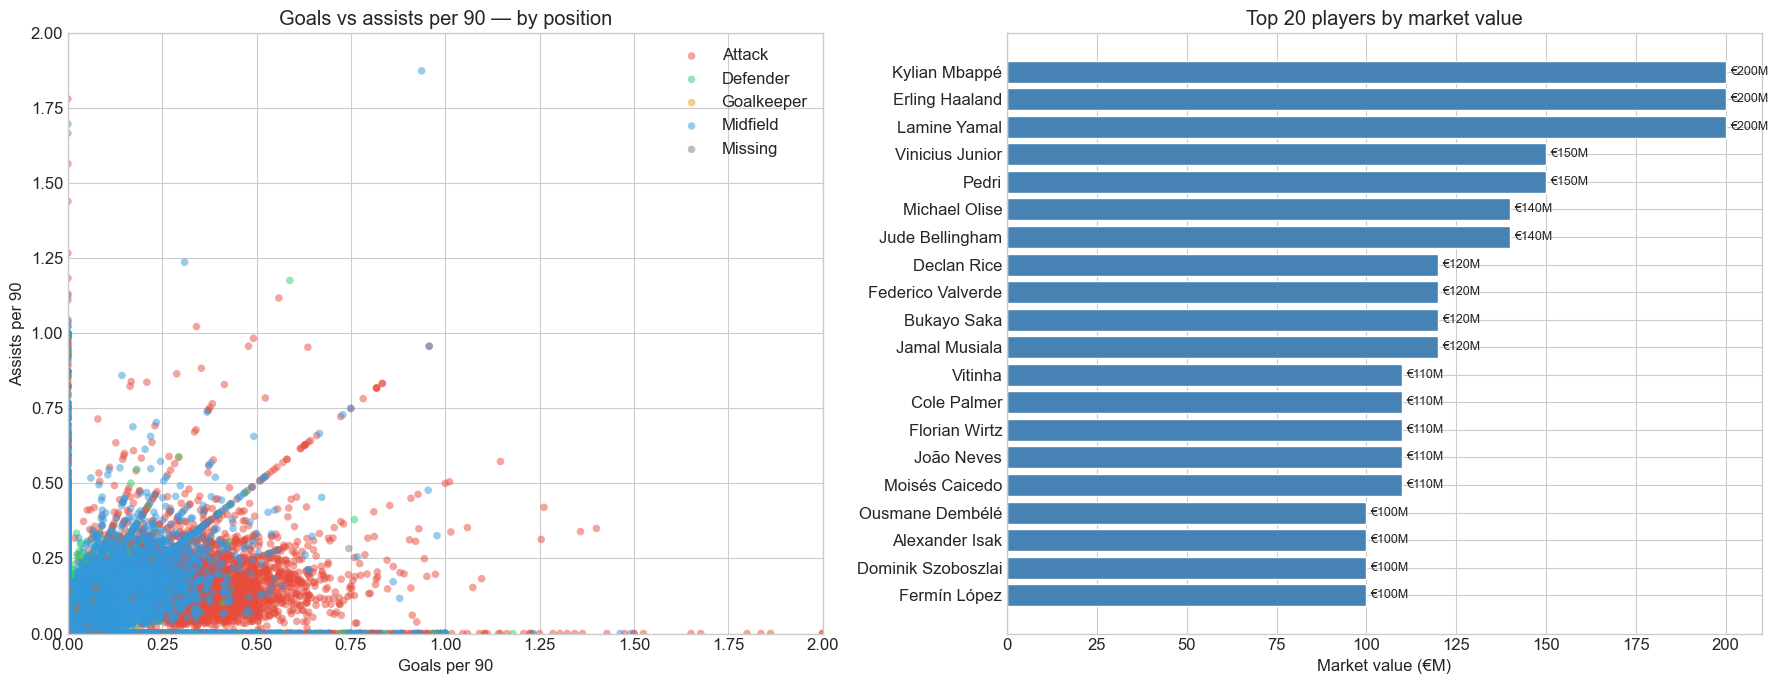

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

pos_colors = {'Attack':'#e74c3c','Midfield':'#3498db',
              'Defender':'#2ecc71','Goalkeeper':'#f39c12'}

for pos, grp in df.groupby('position'):
    ax1.scatter(grp['goals_per90'], grp['assists_per90'],
                c=pos_colors.get(pos,'gray'), label=pos,
                alpha=0.5, s=30, edgecolors='none')

ax1.set_xlabel('Goals per 90')
ax1.set_ylabel('Assists per 90')
ax1.set_title('Goals vs assists per 90 — by position')
ax1.legend()
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 2)

top20 = df.nlargest(20, 'market_value_in_eur')
bars = ax2.barh(top20['name'], top20['market_value_in_eur'] / 1e6,
                color='steelblue', edgecolor='white')
ax2.invert_yaxis()
ax2.set_xlabel('Market value (€M)')
ax2.set_title('Top 20 players by market value')
ax2.bar_label(bars, fmt='€%.0fM', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/scatter_and_top20.png', dpi=150, bbox_inches='tight')
plt.show()